In [8]:
import glob
import json
import re
import csv

# Lấy danh sách toàn bộ các file .json trong thư mục
file_paths = glob.glob('*.json')

# TẬP HỢP CÁC HASHTAG "RÁC": Những từ này xuất hiện quá nhiều nhưng vô nghĩa, cần loại bỏ
stop_hashtags = {'#fyp', '#foryou', '#foryoupage', '#viral','#tiktok','#xyzbca', '#capcut', '#fypシ'}

all_transactions = []

print("Bắt đầu gom và làm sạch dữ liệu...")
for file in file_paths:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for item in data:
            text = item.get('text', '')
            if isinstance(text, str):
                # Trích xuất hashtag và viết thường
                hashtags = re.findall(r'#\w+', text.lower())
                
                # Lọc bỏ các hashtag rác nằm trong danh sách stop_hashtags
                clean_hashtags = [tag for tag in hashtags if tag not in stop_hashtags]
                
                # Chỉ giữ lại những bài đăng có từ 2 hashtag trở lên (mới có thể tạo thành luật kết hợp)
                if len(clean_hashtags) >= 2:
                    all_transactions.append(clean_hashtags)

# Lưu kết quả ra file CSV cực kỳ nhẹ (Mỗi dòng là danh sách hashtag của 1 bài đăng)
output_file = 'cleaned_transactions.csv'
with open(output_file, 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(all_transactions)

print(f"Đã xử lý xong! Đã lưu {len(all_transactions)} hashtag hợp lệ vào file: {output_file}")

Bắt đầu gom và làm sạch dữ liệu...
Đã xử lý xong! Đã lưu 2674 hashtag hợp lệ vào file: cleaned_transactions.csv


In [9]:
import numpy as np
transactions = all_transactions
# Gom tất cả hashtag từ các giao dịch thành một danh sách phẳng (flat list)
all_hashtags = [tag for transaction in transactions for tag in transaction]

# Tính toán các chỉ số
total_posts = len(transactions)
total_hashtags_used = len(all_hashtags)
unique_hashtags = len(set(all_hashtags))
hashtag_lengths = [len(t) for t in transactions]

print("=== TÓM TẮT THỐNG KÊ DỮ LIỆU ===")
print(f"Tổng số bài đăng (Giao dịch): {total_posts:,}")
print(f"Tổng số lượt sử dụng Hashtag: {total_hashtags_used:,}")
print(f"Số lượng Hashtag duy nhất (Unique): {unique_hashtags:,}")
print(f"Trung bình mỗi bài dùng: {np.mean(hashtag_lengths):.1f} hashtag")
print(f"Bài đăng dùng nhiều hashtag nhất: {np.max(hashtag_lengths)} hashtag")
print(f"Bài đăng dùng ít hashtag nhất: {np.min(hashtag_lengths)} hashtag")

=== TÓM TẮT THỐNG KÊ DỮ LIỆU ===
Tổng số bài đăng (Giao dịch): 2,674
Tổng số lượt sử dụng Hashtag: 15,101
Số lượng Hashtag duy nhất (Unique): 7,067
Trung bình mỗi bài dùng: 5.6 hashtag
Bài đăng dùng nhiều hashtag nhất: 152 hashtag
Bài đăng dùng ít hashtag nhất: 2 hashtag


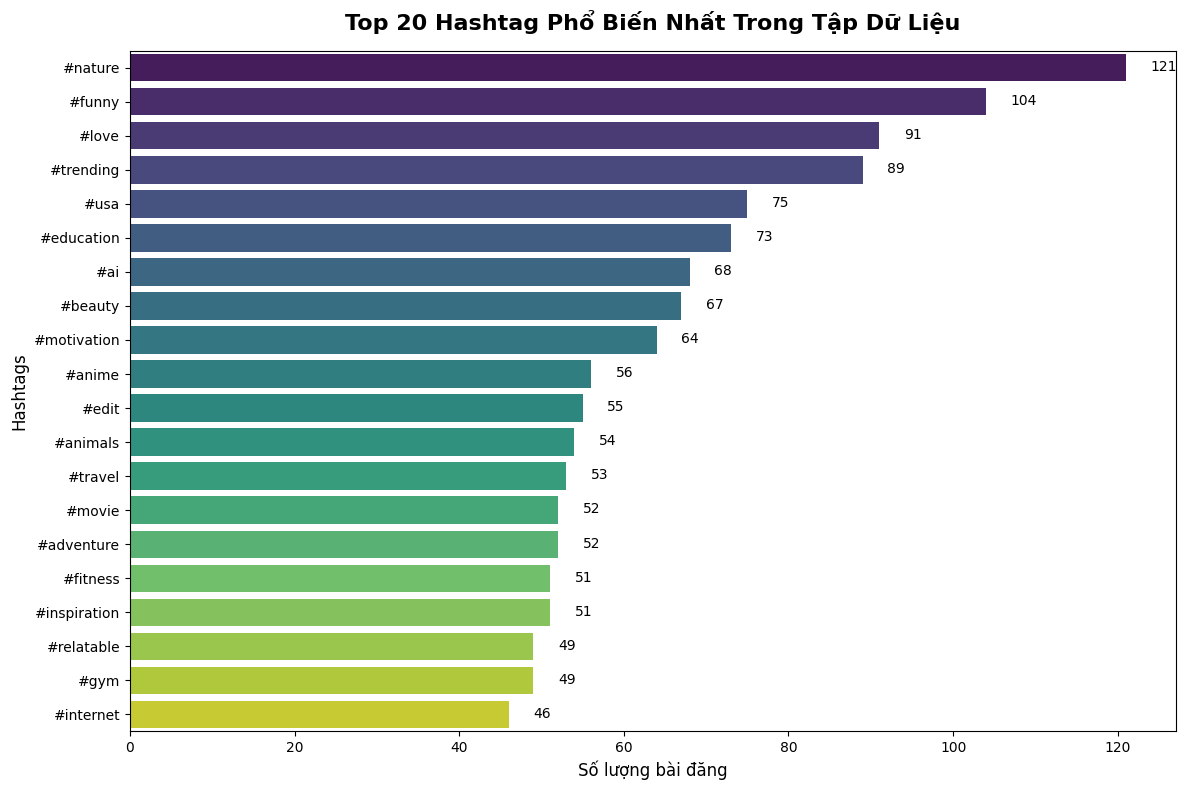

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Đếm tần suất xuất hiện của từng hashtag
hashtag_counts = Counter(all_hashtags)

# Lấy ra 20 hashtag xuất hiện nhiều nhất
top_20_tags = hashtag_counts.most_common(20)
tags, counts = zip(*top_20_tags)

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(tags), palette="viridis")

plt.title('Top 20 Hashtag Phổ Biến Nhất Trong Tập Dữ Liệu', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng bài đăng', fontsize=12)
plt.ylabel('Hashtags', fontsize=12)

# Thêm số liệu cụ thể ở đuôi mỗi cột cho rõ ràng
for i, v in enumerate(counts):
    plt.text(v + 3, i + 0.1, str(v), color='black', fontsize=10)

plt.tight_layout()
plt.show()

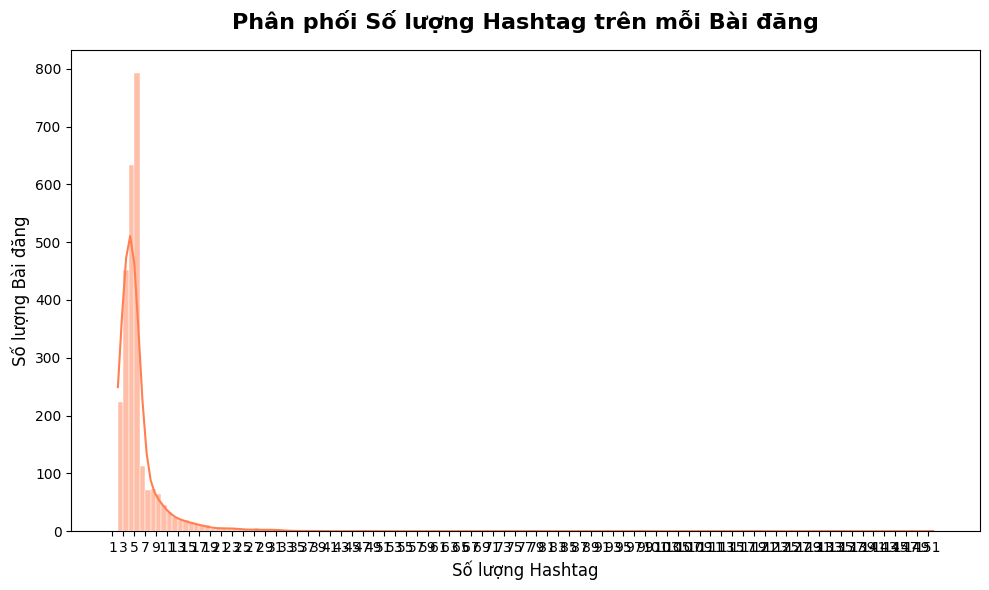

In [11]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Histogram phân phối số lượng hashtag
sns.histplot(hashtag_lengths, bins=range(1, max(hashtag_lengths) + 2), 
             kde=True, color='coral', edgecolor='white')

plt.title('Phân phối Số lượng Hashtag trên mỗi Bài đăng', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng Hashtag', fontsize=12)
plt.ylabel('Số lượng Bài đăng', fontsize=12)

# Căn chỉnh lại trục X để hiển thị số nguyên
plt.xticks(range(1, max(hashtag_lengths) + 1, 2))

plt.tight_layout()
plt.show()

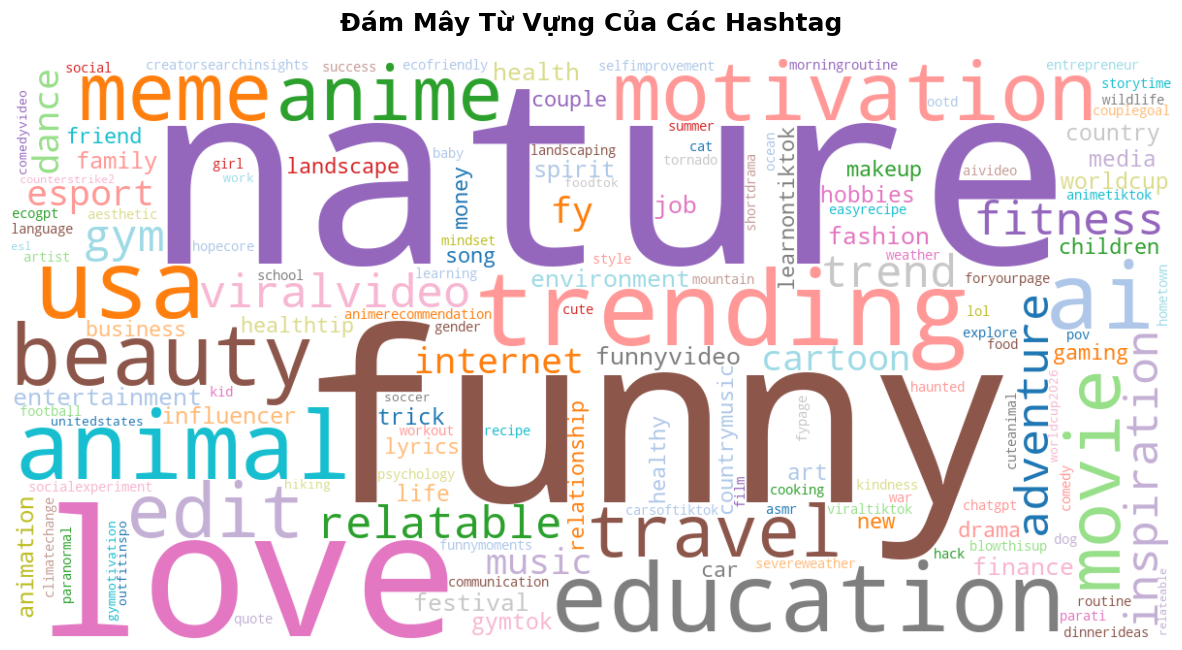

In [12]:
from wordcloud import WordCloud

# Chuyển danh sách hashtag thành một chuỗi văn bản lớn
text_for_wordcloud = ' '.join(all_hashtags)

# Khởi tạo và tạo WordCloud
wordcloud = WordCloud(width=1200, height=600, 
                      background_color='white', 
                      colormap='tab20',
                      collocations=False,
                      max_words=150).generate(text_for_wordcloud)

# Vẽ biểu đồ
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Tắt trục tọa độ
plt.title('Đám Mây Từ Vựng Của Các Hashtag', fontsize=18, fontweight='bold', pad=20)
plt.show()

Tổng số giao dịch đưa vào phân tích: 2674

=== TOP 10 TẬP HASHTAG PHỔ BIẾN NHẤT ===


,support,itemsets
32,0.0453,#nature
2,0.0385,#funny
37,0.0340,#love
23,0.0325,#trending
34,0.0273,#usa
160,0.0273,#education
11,0.0254,#ai
100,0.0251,#beauty
25,0.0239,#motivation
45,0.0209,#anime




Tìm thấy 187 luật kết hợp mạnh.

=== TOP 15 LUẬT KẾT HỢP MẠNH NHẤT (Sắp xếp theo Confidence) ===


,antecedents,consequents,support,confidence,lift
57,#counterstrike2,#esports,0.0041,1.0,76.4000
38,"#animerecommendations, #animetiktok",#anime,0.0037,1.0,47.7500
32,#animetiktok,#anime,0.0060,1.0,47.7500
56,#counterstrike2,#gaming,0.0041,1.0,106.9600
68,#esl,#esports,0.0041,1.0,76.4000
127,#healthtip,"#health, #healthy",0.0034,1.0,133.7000
125,"#healthtip, #healthy",#health,0.0034,1.0,66.8500
124,"#healthtip, #health",#healthy,0.0034,1.0,111.4167
115,#healthtip,"#healthtips, #healthy",0.0034,1.0,157.2941
110,#healthtip,#health,0.0034,1.0,66.8500




=== TOP 15 LUẬT KẾT HỢP YẾU NHẤT (Sắp xếp theo Confidence tăng dần) ===


,antecedents,consequents,support,confidence,lift
3,#trending,#trend,0.0034,0.1034,6.2868
143,#nature,#mountains,0.0049,0.1074,19.1526
150,#nature,#landscape,0.0049,0.1074,9.9065
10,#trending,#funny,0.0037,0.1149,2.9840
9,#nature,#travel,0.0052,0.1157,5.8375
24,#nature,#wildlife,0.0052,0.1157,13.4517
91,#funny,#comedy,0.0045,0.1165,15.5767
103,#usa,#health,0.0034,0.1233,8.2418
154,#love,#hopecore,0.0045,0.1319,16.7912
162,#ai,#chatgpt,0.0034,0.1324,25.2794


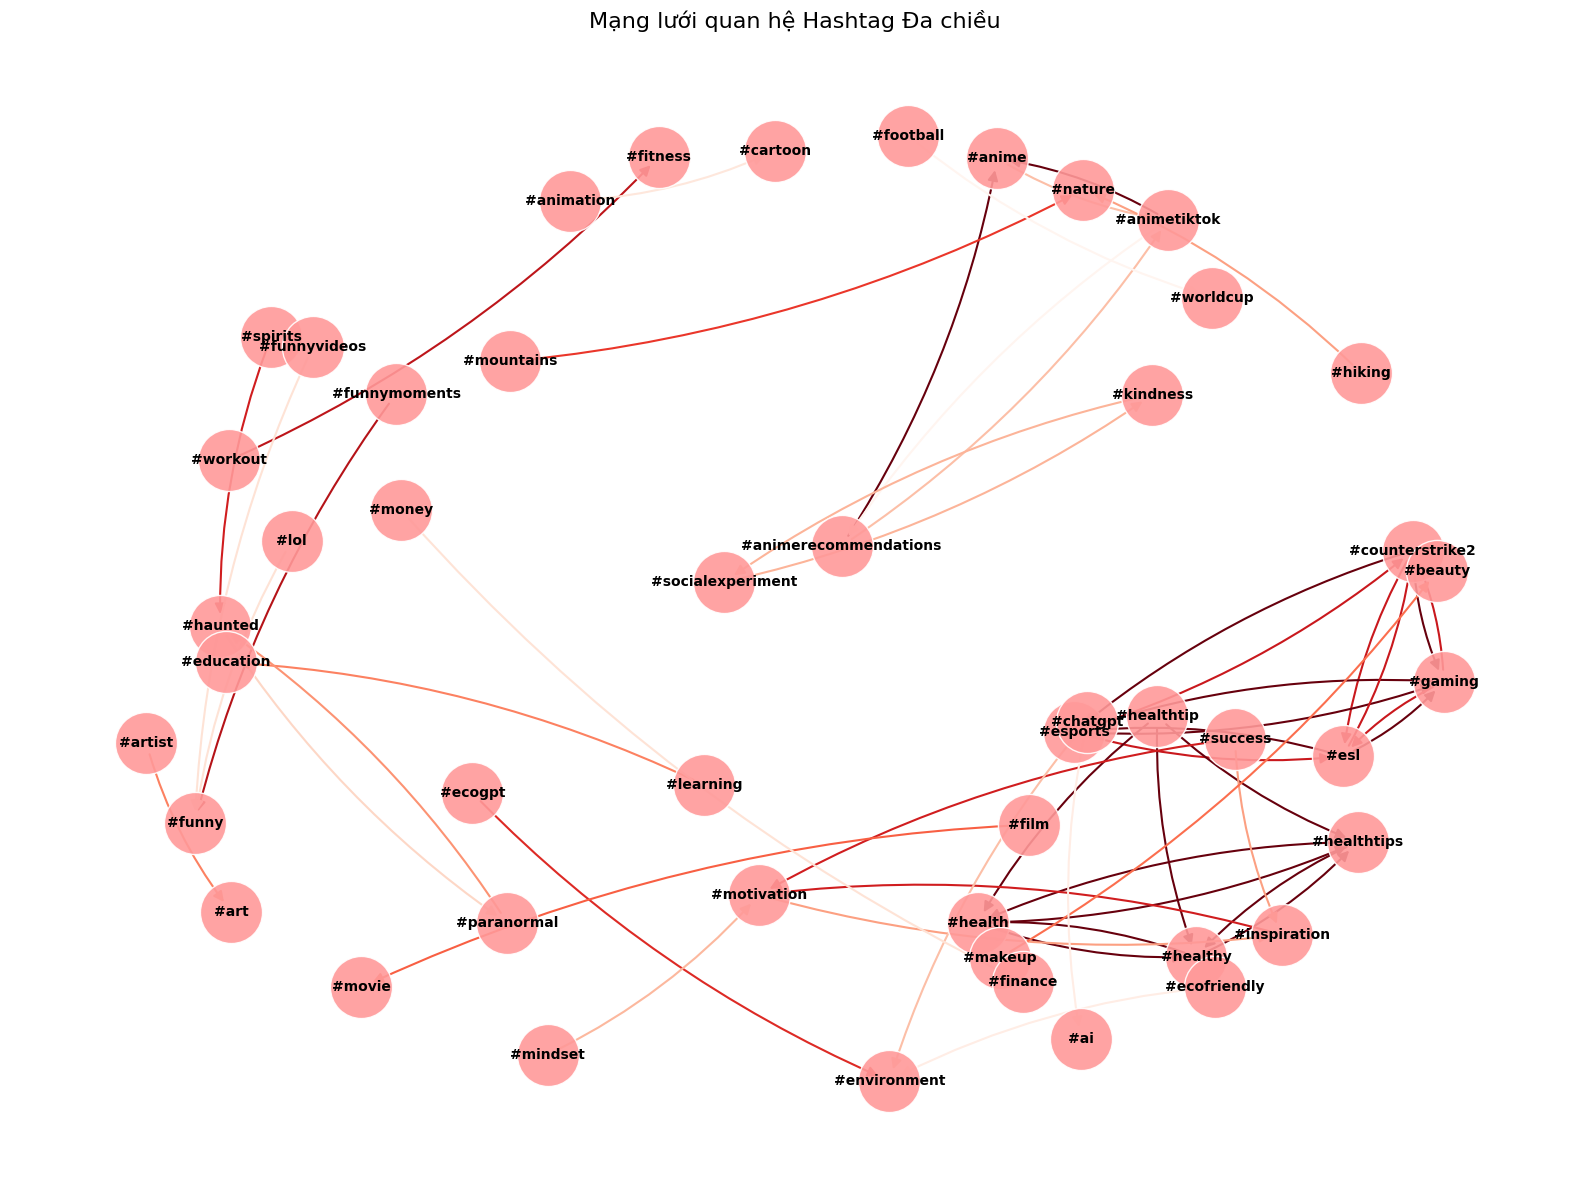

In [13]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

# 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH TỪ FILE CSV
transactions = []
with open('cleaned_transactions.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        transactions.append(row)

print(f"Tổng số giao dịch đưa vào phân tích: {len(transactions)}\n")

# 2. CHUYỂN ĐỔI MA TRẬN
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# 3. CHẠY THUẬT TOÁN FP-GROWTH
frequent_itemsets = fpgrowth(df_encoded, min_support=0.003, max_len=3, use_colnames=True)

# --- BỔ SUNG: IN BẢNG TẬP HASHTAG PHỔ BIẾN ---
print("=== TOP 10 TẬP HASHTAG PHỔ BIẾN NHẤT ===")
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10).copy()
# Chuyển đổi định dạng frozenset thành chuỗi text thông thường cho dễ nhìn
top_itemsets['itemsets'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_itemsets['support'] = top_itemsets['support'].round(4)
try:
    from IPython.display import display
    display(top_itemsets) # Hàm này giúp bảng hiện đẹp mắt trong Jupyter Notebook
except:
    print(top_itemsets.to_string(index=False))
print("\n" + "="*60 + "\n")


# Sinh luật kết hợp
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1, num_itemsets=2)
strong_rules = rules[rules['lift'] > 2.7].sort_values(by='confidence', ascending=False)
print(f"Tìm thấy {len(strong_rules)} luật kết hợp mạnh.\n")

# --- BỔ SUNG: IN BẢNG LUẬT KẾT HỢP CHI TIẾT ---
print("=== TOP 15 LUẬT KẾT HỢP MẠNH NHẤT (Sắp xếp theo Confidence) ===")
# Trích xuất 5 cột quan trọng nhất để làm báo cáo
display_rules = strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()

# Xử lý chuỗi và làm tròn số thập phân
display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_rules['consequents'] = display_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_rules['support'] = display_rules['support'].round(4)
display_rules['confidence'] = display_rules['confidence'].round(4)
display_rules['lift'] = display_rules['lift'].round(4)

# In bảng ra màn hình
try:
    from IPython.display import display
    display(display_rules)
except:
    print(display_rules.to_string(index=False))
print("\n" + "="*60 + "\n")

# --- BỔ SUNG: IN BẢNG 15 LUẬT KẾT HỢP YẾU NHẤT ---
print("=== TOP 15 LUẬT KẾT HỢP YẾU NHẤT (Sắp xếp theo Confidence tăng dần) ===")

# Lấy 15 luật có confidence thấp nhất từ tập 'rules' ban đầu
weak_rules = rules.sort_values(by='confidence', ascending=True).head(15).copy()

# Trích xuất 5 cột quan trọng
display_weak_rules = weak_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

# Xử lý chuỗi và làm tròn số thập phân
display_weak_rules['antecedents'] = display_weak_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
display_weak_rules['consequents'] = display_weak_rules['consequents'].apply(lambda x: ', '.join(list(x)))
display_weak_rules['support'] = display_weak_rules['support'].round(4)
display_weak_rules['confidence'] = display_weak_rules['confidence'].round(4)
display_weak_rules['lift'] = display_weak_rules['lift'].round(4)

# In bảng ra màn hình
try:
    from IPython.display import display
    display(display_weak_rules)
except:
    print(display_weak_rules.to_string(index=False))
print("\n" + "="*60 + "\n")
# 4. VẼ BIỂU ĐỒ MẠNG LƯỚI
top_rules = strong_rules.head(80) # Vẽ 50 luật mạnh nhất

plt.figure(figsize=(16, 12))
G = nx.DiGraph()

# Duyệt qua từng luật
for i, row in top_rules.iterrows():
    # Lấy TẤT CẢ các hashtag ở vế trái và vế phải
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])
    
    # Tạo đường nối từ MỌI hashtag vế trái sang MỌI hashtag vế phải
    for ant in antecedents:
        for con in consequents:
            # Nếu cạnh đã tồn tại, có thể cộng dồn trọng số, hoặc cập nhật
            if G.has_edge(ant, con):
                G[ant][con]['weight'] = max(G[ant][con]['weight'], row['confidence'])
            else:
                G.add_edge(ant, con, weight=row['confidence'])

# Cấu hình vẽ đồ thị
pos = nx.spring_layout(G, k=0.8) # Tăng k để các node đẩy nhau ra xa hơn, tránh dính chùm
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='#ff9999', alpha=0.9, edgecolors='white')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, 
                       edge_color=edge_weights, edge_cmap=plt.cm.Reds, width=1.5,
                       connectionstyle="arc3,rad=0.1") # rad=0.1 tạo đường cong để thấy rõ mũi tên 2 chiều

plt.title('Mạng lưới quan hệ Hashtag Đa chiều', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()